# Comparison of bed output of rastair and rastair2

Let's load data and check if the two agree

In [14]:
suppressPackageStartupMessages({
    library("data.table")
    library("ggplot2")
    library("ggVennDiagram")
    library("rtracklayer")
    library("Biostrings")
})

params <- list(threads = 8,
               rastair1 = "../rastair/target/release/rastair",
               rastair2 = "target/release/rastair2",
               test_fasta = "tests/data/test.fasta.gz",
               test_bam = "tests/data/test.bam")

First, we run rastair 1 and load the output directly:

In [35]:
rastair.1 <- fread(cmd=paste0(params$rastair1, " call -F 3852 -q 1 -Q 10 -l bacteriophage_lambda_CpG -r ", params$test_fasta, " ", params$test_bam), header=TRUE, stringsAsFactors=TRUE)
setnames(rastair.1, 1, "chr")

Next, we need to run rastair 2 and demand bed output, then parse this:

In [36]:
rastair.2 <- fread(cmd=paste(params$rastair2, "call -l bacteriophage_lambda_CpG -q 1 -Q 10 --cpgs-only -F 3852 -r", params$test_fasta, params$test_bam), header=TRUE, stringsAsFactors=TRUE)
setnames(rastair.2, 1, "chr")
unlink(outfile)

In [37]:
dim(rastair.2)

[1] 6173   15

In [38]:
dim(rastair.1)

[1] 6109   14

Some differences... Let's look at the distribution of values

[1] 6109    5

Warning message:
“Removed 310 rows containing missing values or values outside the scale range (`geom_point()`).”


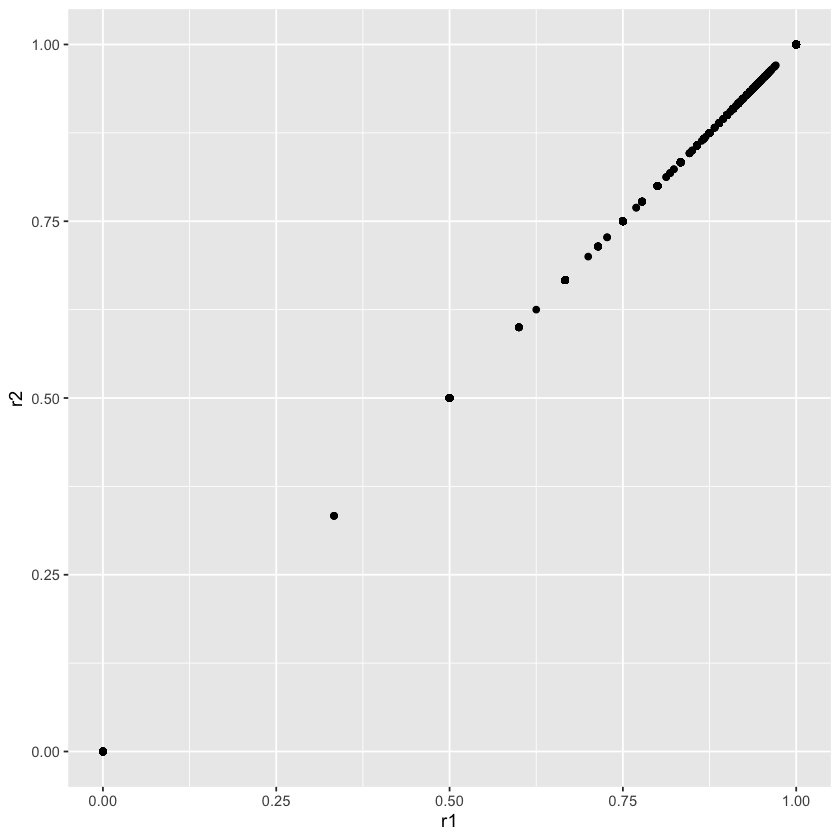

In [39]:
setkey(rastair.1, chr, start, end)
setkey(rastair.2, chr, start, end)
r1_vs_r2 <- rastair.1[rastair.2, nomatch=NULL][, .(chr, start, end, r1 = mod/(mod+unmod), r2=i.mod/(i.mod+i.unmod))]

dim(r1_vs_r2)

ggplot(r1_vs_r2, aes(x=r1, y=r2)) + geom_point()

No differences there. Why are there different numbers of rows in rastair2?

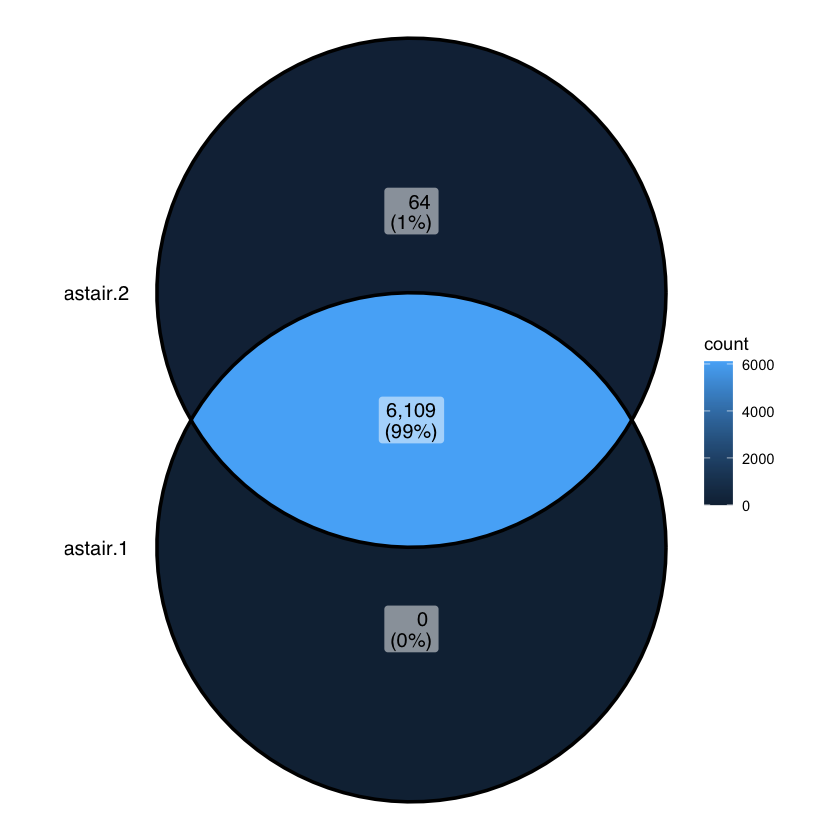

In [40]:
ggVennDiagram(list(rastair.1=paste(rastair.1$chr, rastair.1$start, sep="_"), rastair.2=paste(rastair.2$chr, rastair.2$start, sep="_")))

392 additional rows. Are these all de-novo?

In [41]:
rastair.1.exclusive <- rastair.2[rastair.1][is.na(mod), .(chr, start, end, beta_est=i.beta_est, mod=i.mod, unmod=i.unmod, snp=i.snp, no_snp=i.no_snp)]
dim(rastair.1.exclusive)

[1] 0 8

No rows that are unique to Rastair1, that's good!

What about the inverse, ie positions that are exclusive to rastair.2?

In [42]:
rastair.2.exclusive <- rastair.1[rastair.2][is.na(mod), .(chr, start, end, beta_est=i.beta_est, mod=i.mod, unmod=i.unmod, snp=i.snp, no_snp=i.no_snp, cpg)]
dim(rastair.2.exclusive)

[1] 64  9

In [43]:
rastair.2[, .N, by=cpg]
rastair.2.exclusive[, .N, by=cpg]
summary(rastair.2.exclusive$mod)
summary(rastair.2.exclusive$unmod)
summary(rastair.2.exclusive$unmod==0 & rastair.2.exclusive$mod==0)

cpg,N
<fct>,<int>
REF,6109
NEW,64


cpg,N
<fct>,<int>
NEW,64


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.01562 0.00000 1.00000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   6.031   9.500  30.000 

   Mode   FALSE    TRUE 
logical      28      36 

These are de-novo CpGs! However, a lot of them have no evidence for `mod` nor `unmod`, so there is only evidence for a SNP but no coverage to prove methylation.